In [5]:
# ==================== DONNÉES DU STRATÈGE : tout se règle dans cette cellule ====================

# ----- Le Grand Prix -----
YEAR = 2024
GRAND_PRIX = 'Hungary'          # pays ou ville, en anglais : 'Spain', 'Azerbaijan', 'Monza', 'Bahrain'...
RACE_LAPS = 70                # nombre de tours de la course

# ----- Pour qui calcule-t-on ? -----
DRIVER = 'NOR'                # code à trois lettres du pilote, ou None
TEAM = 'McLaren'              # nom de l'écurie, ou None (une erreur de saisie affiche les noms disponibles)

# ----- Trains de pneus disponibles pour la course : (composé, tours déjà roulés) -----
# Les relais d'une stratégie sont affichés dans l'ordre de cette liste.
AVAILABLE_SETS = [
    ('SOFT', 3),
    ('SOFT', 0),
    ('MEDIUM', 0),
    ('HARD', 0),
    ('HARD', 0),
]

# ----- Coefficient d'usure : usure en course = coefficient × usure mesurée en essais -----
# Sur quatre circuits en 2023 et 2024, il a valu entre 0,35 et 0,80, souvent autour de 0,6.
RACE_WEAR_COEFFICIENT = 0.6

# ----- Hypothèses (non mesurables en essais libres) -----
PRACTICE_SESSIONS = ['FP1', 'FP2', 'FP3']    # essais libres utilisés pour mesurer l'usure
FUEL_EFFECT_PER_LAP = 0.05                   # gain dû à l'allègement (s/tour)
COMPOUND_OFFSET_S = {'SOFT': 0.0, 'MEDIUM': 0.3, 'HARD': 0.6}    # retard d'un pneu neuf sur le Soft neuf (s/tour)
MAX_STOPS = 3                                # nombre maximal d'arrêts testés
MIN_STINT_LAPS = 5                           # longueur minimale d'un relais (tours)
# Âge maximal d'un pneu en fin de relais (tours déjà roulés compris).
# None = mesuré sur la course de l'année précédente ; un nombre impose la valeur.
MAX_TYRE_AGE = {'SOFT': 25, 'MEDIUM': None, 'HARD': None}

In [6]:
import sys
sys.path.insert(0, '..')    # pour importer le code du dossier src/, situé un niveau au-dessus du notebook

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.cleaning import select_long_run_laps
from src.data_loader import get_event_name, load_laps
from src.degradation import COMPOUNDS, select_wear
from src.strategy import describe_stints, find_best_strategies, measure_max_tyre_age, measure_pit_loss

fastf1.set_log_level('ERROR')    # masque les messages INFO / WARNING de FastF1

# Rappel de la saisie, avec le nom du Grand Prix tel que FastF1 l'a compris
print(f'Grand Prix reconnu : {get_event_name(YEAR, GRAND_PRIX)} {YEAR}, {RACE_LAPS} tours')
print(f"Pilote : {DRIVER}   Écurie : {TEAM}   Coefficient d'usure : {RACE_WEAR_COEFFICIENT}")

# --- Tours de longs relais des essais libres ---
practice_laps = pd.concat([load_laps(YEAR, GRAND_PRIX, name) for name in PRACTICE_SESSIONS], ignore_index=True)
long_run_laps = select_long_run_laps(practice_laps)

# Vérification de la saisie : pilote, écurie et composés doivent exister dans les données
drivers_by_team = practice_laps.groupby('Team')['Driver'].unique()
if DRIVER is not None and DRIVER not in practice_laps['Driver'].values:
    raise ValueError(f'Pilote inconnu : {DRIVER}. Pilotes disponibles : {sorted(practice_laps["Driver"].unique())}')
if TEAM is not None and TEAM not in drivers_by_team.index:
    raise ValueError(f'Écurie inconnue : {TEAM}. Écuries disponibles : {list(drivers_by_team.index)}')
unknown_compounds = {compound for compound, _ in AVAILABLE_SETS} - set(COMPOUNDS)
if unknown_compounds:
    raise ValueError(f'Composé inconnu : {unknown_compounds}. Composés possibles : {COMPOUNDS}')

# Périmètres de données, du plus précis au plus large. Chacun est un masque sur long_run_laps.
ALL_DRIVERS = 'Tous les pilotes'
scopes = {}
if DRIVER is not None:
    scopes[f'Pilote {DRIVER}'] = long_run_laps['Driver'] == DRIVER
    # L'écurie du pilote sert de repli pour les composés qu'il n'a pas roulés
    driver_team = practice_laps.loc[practice_laps['Driver'] == DRIVER, 'Team'].iloc[0]
    scopes[f'Écurie {driver_team}'] = long_run_laps['Team'] == driver_team
if TEAM is not None:
    scopes[f'Écurie {TEAM}'] = long_run_laps['Team'] == TEAM
scopes[ALL_DRIVERS] = pd.Series(True, index=long_run_laps.index)

# Périmètres pour lesquels on affichera une stratégie : ceux demandés dans la saisie, plus tous les pilotes
shown_scopes = [name for name in scopes
                if name in (f'Pilote {DRIVER}', f'Écurie {TEAM}', ALL_DRIVERS)]

print(f'Tours roulés en essais : {len(practice_laps)}, dont {len(long_run_laps)} tours de longs relais gardés')

# Nombre de tours de longs relais par périmètre et par composé
pd.DataFrame({name: long_run_laps[scopes[name]]['Compound'].value_counts() for name in shown_scopes}
             ).reindex(COMPOUNDS).fillna(0).astype(int)

Grand Prix reconnu : Hungarian Grand Prix 2024, 70 tours
Pilote : NOR   Écurie : McLaren   Coefficient d'usure : 0.6
Tours roulés en essais : 1296, dont 245 tours de longs relais gardés


,Pilote NOR,Écurie McLaren,Tous les pilotes
Compound,,,
SOFT,0,0,54
MEDIUM,0,11,160
HARD,7,7,31


In [7]:
# --- Usure des pneus retenue pour chaque périmètre ---
# Pour un périmètre donné, chaque composé prend la mesure la plus précise disponible :
# d'abord le pilote, sinon son écurie, sinon tous les pilotes (colonne Source).
scope_names = list(scopes)
wear_tables = {}
for name in shown_scopes:
    fallback_chain = {n: scopes[n] for n in scope_names[scope_names.index(name):]}
    table = select_wear(long_run_laps, fallback_chain, FUEL_EFFECT_PER_LAP)
    table['Usure course (s/tour)'] = RACE_WEAR_COEFFICIENT * table['Usure essais (s/tour)']
    wear_tables[name] = table

pd.concat(wear_tables, names=['Périmètre', 'Composé']).round(3)

Usure essais (s/tour)  ± usure  Relais  \
Périmètre        Composé                                           
Pilote NOR       SOFT                     0.193    0.041       8   
                 MEDIUM                   0.009    0.019       1   
                 HARD                     0.156    0.036       1   
Écurie McLaren   SOFT                     0.193    0.041       8   
                 MEDIUM                   0.009    0.019       1   
                 HARD                     0.156    0.036       1   
Tous les pilotes SOFT                     0.193    0.041       8   
                 MEDIUM                   0.147    0.013      19   
                 HARD                     0.112    0.016       4   

                                    Source  Usure course (s/tour)  
Périmètre        Composé                                           
Pilote NOR       SOFT     Tous les pilotes                  0.116  
                 MEDIUM     Écurie McLaren                  0.005  
                 HARD           Pilote NOR                  0.093  
Écurie McLaren   SOFT     Tous les pilotes                  0.116  
                 MEDIUM     Écurie McLaren                  0.005  
                 HARD       Écurie McLaren                  0.093  
Tous les pilotes SOFT     Tous les pilotes                  0.116  
                 MEDIUM   Tous les pilotes                  0.088  
                 HARD     Tous les pilotes                  0.067

In [8]:
# --- Ce que la course de l'année précédente apporte (même circuit) ---
previous_race_laps = load_laps(YEAR - 1, GRAND_PRIX, 'R')

# Temps perdu à un arrêt
pit_in_loss, pit_out_loss = measure_pit_loss(previous_race_laps)
pit_loss = pit_in_loss + pit_out_loss
print(f"Temps perdu au tour d'entrée  : {pit_in_loss:.1f} s")
print(f'Temps perdu au tour de sortie : {pit_out_loss:.1f} s')
print(f"Coût total d'un arrêt         : {pit_loss:.1f} s  (course {YEAR - 1})")

# Âge maximal d'un pneu : la valeur saisie si elle existe, sinon celle mesurée sur la course précédente
measured_max_age = measure_max_tyre_age(previous_race_laps)
max_tyre_age = {}
rows = []
for compound in COMPOUNDS:
    if MAX_TYRE_AGE[compound] is not None:
        max_tyre_age[compound], source = MAX_TYRE_AGE[compound], 'saisie'
    elif compound in measured_max_age.index:
        max_tyre_age[compound] = measured_max_age.loc[compound, 'Âge max (tours)']
        source = f"course {YEAR - 1} ({measured_max_age.loc[compound, 'Relais']} relais)"
    elif compound in {c for c, _ in AVAILABLE_SETS}:
        raise ValueError(f"Le {compound} n'a pas été assez utilisé en course {YEAR - 1} pour mesurer son âge "
                         'maximal : saisis une valeur dans MAX_TYRE_AGE.')
    else:
        continue    # composé ni mesuré ni disponible : il ne sert pas
    rows.append({'Composé': compound, 'Âge max (tours)': max_tyre_age[compound], 'Source': source})

pd.DataFrame(rows).set_index('Composé')

Temps perdu au tour d'entrée  : 2.5 s
Temps perdu au tour de sortie : 19.0 s
Coût total d'un arrêt         : 21.5 s  (course 2023)


,Âge max (tours),Source
Composé,,
SOFT,25,saisie
MEDIUM,31,course 2023 (23 relais)
HARD,37,course 2023 (28 relais)


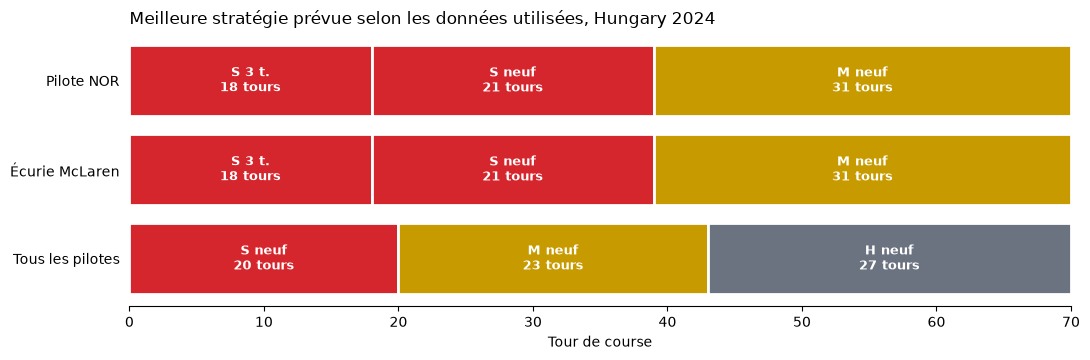

Relais  \
Périmètre        Arrêts                                                      
Pilote NOR       2       SOFT 3 t. roulés : 18 tours / SOFT neuf : 21 t...   
                 3       SOFT 3 t. roulés : 12 tours / SOFT neuf : 15 t...   
Écurie McLaren   2       SOFT 3 t. roulés : 18 tours / SOFT neuf : 21 t...   
                 3       SOFT 3 t. roulés : 12 tours / SOFT neuf : 15 t...   
Tous les pilotes 2       SOFT neuf : 20 tours / MEDIUM neuf : 23 tours ...   
                 3       SOFT neuf : 16 tours / MEDIUM neuf : 17 tours ...   

                        Tours d'arrêt  Écart (s)  
Périmètre        Arrêts                           
Pilote NOR       2           (18, 39)        0.0  
                 3       (12, 27, 58)       10.3  
Écurie McLaren   2           (18, 39)        0.0  
                 3       (12, 27, 58)       10.3  
Tous les pilotes 2           (20, 43)        0.0  
                 3       (16, 33, 51)        5.2

In [9]:
# --- Meilleure stratégie pour chaque périmètre de données ---
COMPOUND_COLORS = {'SOFT': '#d6262d', 'MEDIUM': '#c79a00', 'HARD': '#6b7280'}    # couleurs usuelles Pirelli

strategies = {}
for name in shown_scopes:
    race_wear = wear_tables[name]['Usure course (s/tour)'].to_dict()
    strategies[name] = find_best_strategies(AVAILABLE_SETS, RACE_LAPS, race_wear, COMPOUND_OFFSET_S,
                                            pit_loss, MAX_STOPS, max_tyre_age, MIN_STINT_LAPS)

# Une barre par périmètre : sa meilleure stratégie, un segment par relais
fig, ax = plt.subplots(figsize=(11, 0.7 * len(shown_scopes) + 1.6))
for row, name in enumerate(shown_scopes):
    first_lap = 0
    for compound, used_laps, n_laps in strategies[name].loc[0, 'Relais']:
        ax.barh(row, n_laps, left=first_lap, color=COMPOUND_COLORS[compound], edgecolor='white', linewidth=2)
        tyre_state = 'neuf' if used_laps == 0 else f'{used_laps} t.'
        ax.text(first_lap + n_laps / 2, row, f'{compound[0]} {tyre_state}\n{n_laps} tours', ha='center',
                va='center', fontsize=9, color='white', fontweight='bold')
        first_lap += n_laps
ax.set_yticks(range(len(shown_scopes)), shown_scopes)
ax.invert_yaxis()    # le périmètre le plus précis en haut
ax.set_xlim(0, RACE_LAPS)
ax.set_xlabel('Tour de course')
ax.set_title(f'Meilleure stratégie prévue selon les données utilisées, {GRAND_PRIX} {YEAR}', loc='left')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig(f'../figures/predicted_strategies_{GRAND_PRIX}_{YEAR}.png'.lower(), dpi=150, bbox_inches='tight')
plt.show()

# Pour chaque périmètre : la meilleure stratégie à 1, 2 et 3 arrêts, et son écart à la meilleure
best_by_stops = pd.concat({name: table.drop_duplicates('Arrêts').set_index('Arrêts').sort_index()
                           for name, table in strategies.items()}, names=['Périmètre', 'Arrêts'])
best_by_stops['Relais'] = best_by_stops['Relais'].map(describe_stints)
best_by_stops[['Relais', "Tours d'arrêt", 'Écart (s)']].round(1)

In [10]:
# --- Et si les hypothèses étaient différentes ? ---
# On refait la recherche, pour le périmètre le plus précis, en changeant une hypothèse à la fois.
COEFFICIENT_RANGE = (0.35, 0.8)    # valeurs extrêmes du coefficient d'usure observées en 2023 et 2024

main_scope = shown_scopes[0]
practice_wear = wear_tables[main_scope]['Usure essais (s/tour)']
scenarios = {
    'Saisie actuelle': (RACE_WEAR_COEFFICIENT, COMPOUND_OFFSET_S),
    f'Coefficient d\'usure {COEFFICIENT_RANGE[0]}': (COEFFICIENT_RANGE[0], COMPOUND_OFFSET_S),
    f'Coefficient d\'usure {COEFFICIENT_RANGE[1]}': (COEFFICIENT_RANGE[1], COMPOUND_OFFSET_S),
    'Aucun écart entre composés': (RACE_WEAR_COEFFICIENT, {c: 0.0 for c in COMPOUNDS}),
    'Écarts entre composés doublés': (RACE_WEAR_COEFFICIENT, {c: 2 * gap for c, gap in COMPOUND_OFFSET_S.items()}),
}

rows = []
for name, (coefficient, compound_offset) in scenarios.items():
    result = find_best_strategies(AVAILABLE_SETS, RACE_LAPS, (coefficient * practice_wear).to_dict(),
                                  compound_offset, pit_loss, MAX_STOPS, max_tyre_age, MIN_STINT_LAPS)
    best = result.iloc[0]
    # Meilleure stratégie ayant un autre nombre d'arrêts, pour mesurer la marge
    runner_up = result[result['Arrêts'] != best['Arrêts']].iloc[0]
    rows.append({
        'Scénario': name,
        'Arrêts': best['Arrêts'],
        'Relais': describe_stints(best['Relais']),
        "Tours d'arrêt": best["Tours d'arrêt"],
        "Autre nombre d'arrêts": f"{runner_up['Arrêts']} arrêt(s) : +{runner_up['Écart (s)']:.1f} s",
    })
print(f'Périmètre testé : {main_scope}')
pd.DataFrame(rows).set_index('Scénario')

Périmètre testé : Pilote NOR


,Arrêts,Relais,Tours d'arrêt,Autre nombre d'arrêts
Scénario,,,,
Saisie actuelle,2,SOFT 3 t. roulés : 18 tours / SOFT neuf : 21 t...,"(18, 39)",3 arrêt(s) : +10.3 s
Coefficient d'usure 0.35,2,SOFT 3 t. roulés : 18 tours / SOFT neuf : 21 t...,"(18, 39)",3 arrêt(s) : +17.7 s
Coefficient d'usure 0.8,2,SOFT neuf : 20 tours / MEDIUM neuf : 31 tours ...,"(20, 51)",3 arrêt(s) : +6.3 s
Aucun écart entre composés,2,MEDIUM neuf : 31 tours / HARD neuf : 19 tours ...,"(31, 50)",3 arrêt(s) : +11.4 s
Écarts entre composés doublés,2,SOFT 3 t. roulés : 18 tours / SOFT neuf : 21 t...,"(18, 39)",3 arrêt(s) : +16.5 s


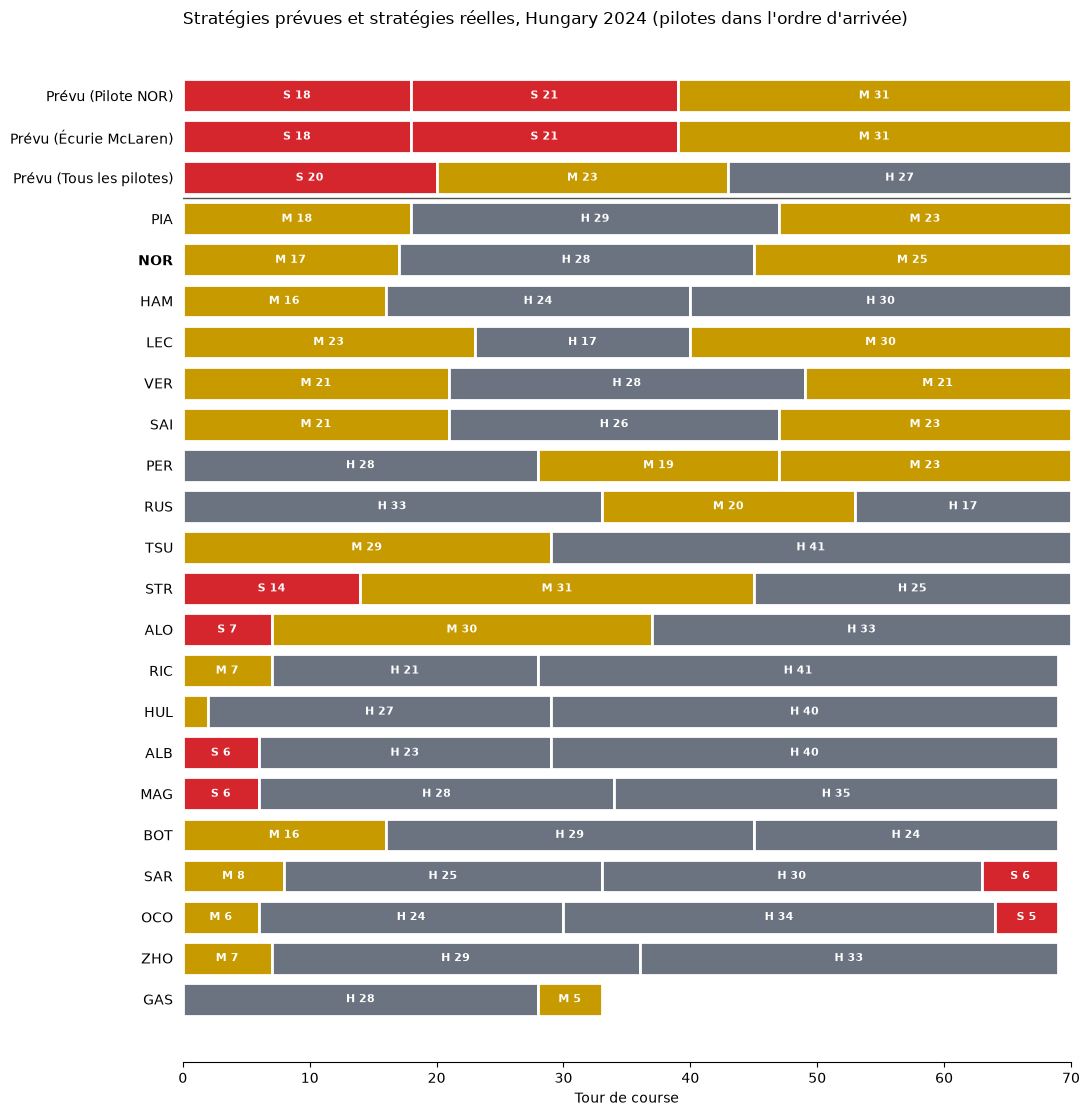

,Arrêts,Tours d'arrêt,Relais
Pilote,,,
PIA,2,"(18, 47)",MEDIUM neuf : 18 tours / HARD 1 t. roulé : 29 ...
NOR,2,"(17, 45)",MEDIUM neuf : 17 tours / HARD 1 t. roulé : 28 ...
HAM,2,"(16, 40)",MEDIUM neuf : 16 tours / HARD neuf : 24 tours ...
LEC,2,"(23, 40)",MEDIUM neuf : 23 tours / HARD neuf : 17 tours ...
VER,2,"(21, 49)",MEDIUM neuf : 21 tours / HARD neuf : 28 tours ...
SAI,2,"(21, 47)",MEDIUM neuf : 21 tours / HARD neuf : 26 tours ...
PER,2,"(28, 47)",HARD neuf : 28 tours / MEDIUM neuf : 19 tours ...
RUS,2,"(33, 53)",HARD neuf : 33 tours / MEDIUM neuf : 20 tours ...
TSU,1,"(29,)",MEDIUM neuf : 29 tours / HARD neuf : 41 tours


In [11]:
# --- Stratégies réellement utilisées en course, pour comparer avec la prévision ---
# Cette cellule n'a de sens que si la course a déjà eu lieu.
OTHER_COMPOUND_COLOR = '#3b82a0'    # pneus pluie ou composé non renseigné
MIN_LABEL_LAPS = 4                  # en dessous, le relais est trop étroit pour y écrire son nombre de tours

try:
    race_laps = load_laps(YEAR, GRAND_PRIX, 'R')
except Exception as error:
    raise RuntimeError(f'Course {GRAND_PRIX} {YEAR} indisponible : elle n\'a peut-être pas encore eu lieu.') from error

# Un relais par ligne : composé, tours déjà roulés au départ du relais, longueur
race_stints = race_laps.groupby(['Driver', 'Stint']).agg(
    compound=('Compound', 'first'), used_laps=('TyreLife', lambda age: int(age.min()) - 1),
    n_laps=('LapNumber', 'size'))
real_strategies = {driver: [tuple(stint) for stint in stints.itertuples(index=False)]
                   for driver, stints in race_stints.groupby('Driver')}

# Pilotes dans l'ordre d'arrivée : le plus de tours bouclés, puis le premier à finir son dernier tour
last_laps = race_laps.sort_values('LapNumber').groupby('Driver').tail(1)
finishing_order = list(last_laps.sort_values(['LapNumber', 'Time'], ascending=[False, True])['Driver'])

# Lignes du graphique : d'abord les prévisions, puis les pilotes
rows = [(f'Prévu ({name})', strategies[name].loc[0, 'Relais']) for name in shown_scopes]
rows += [(driver, real_strategies[driver]) for driver in finishing_order]

fig, ax = plt.subplots(figsize=(11, 0.42 * len(rows) + 1.6))
for row, (label, stints) in enumerate(rows):
    first_lap = 0
    for compound, used_laps, n_laps in stints:
        ax.barh(row, n_laps, left=first_lap, color=COMPOUND_COLORS.get(compound, OTHER_COMPOUND_COLOR),
                edgecolor='white', linewidth=2)
        if n_laps >= MIN_LABEL_LAPS:
            ax.text(first_lap + n_laps / 2, row, f'{compound[0]} {n_laps}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
        first_lap += n_laps
ax.axhline(len(shown_scopes) - 0.5, color='#52514e', linewidth=1)    # sépare les prévisions des pilotes
ax.set_yticks(range(len(rows)), [label for label, _ in rows])
for tick, (label, _) in zip(ax.get_yticklabels(), rows):
    if label == DRIVER:
        tick.set_fontweight('bold')    # le pilote saisi ressort
ax.invert_yaxis()    # prévisions en haut, puis le vainqueur
ax.set_xlim(0, RACE_LAPS)
ax.set_xlabel('Tour de course')
ax.set_title(f'Stratégies prévues et stratégies réelles, {GRAND_PRIX} {YEAR} (pilotes dans l\'ordre d\'arrivée)',
             loc='left')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig(f'../figures/real_strategies_{GRAND_PRIX}_{YEAR}.png'.lower(), dpi=150, bbox_inches='tight')
plt.show()

# Le détail en tableau : nombre d'arrêts, tours d'arrêt et relais de chaque pilote
pd.DataFrame([{'Pilote': driver,
               'Arrêts': len(real_strategies[driver]) - 1,
               "Tours d'arrêt": tuple(int(lap) for lap in np.cumsum([n for _, _, n in real_strategies[driver]])[:-1]),
               'Relais': describe_stints(real_strategies[driver])}
              for driver in finishing_order]).set_index('Pilote')